<div data-caja-markdown="1" style="border: 1px solid #bdbdbd; border-radius: 8px; padding: 14px 16px; margin: 8px 0; background-color: #fafafa;">

## Luna Marcelo — Aprendizaje Profundo — TP1 — Cohorte 24 - Experimento Adicional

</div>



#### 1. La siguiente celda importa las bibliotecas base: NumPy, SciPy y Matplotlib. 


In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", mpl.__version__)

NumPy: 2.4.3
SciPy: 1.17.1
Matplotlib: 3.10.8


#### 2. Introducción y Generación del Dataset Sintético con el mismo criterio que el ejercicio principal

In [8]:
# --- Parámetros del muestreo en x (consigna: n >= 200, linspace en rango simétrico) ---
#n = 250
n= 500
ini, fin = -4.0, 4.0
_x = np.linspace(ini, fin, n)

# --- Señal determinista: parte dominante "tipo sigmoide" + oscilación pequeña ---
# La tangente hiperbólica tanh(k*x) es acotada y en forma de S (misma familia de no linealidad
# que una sigmoide logística, adecuada como término principal suave).
A = 1.0
k = 0.8  # pendiente de la S; valores ~0.5–1 mantienen la transición visible en [-4, 4]

# Perturbación trigonométrica: |B| debe ser claramente menor que |A| para no dominar la forma.
B = 0.2
omega = 1.5  # frecuencia moderada (evita muchas oscilaciones en el intervalo)

senal = A * np.tanh(k * _x) + B * np.sin(omega * _x)

# --- Ruido aleatorio (np.random): ruido gaussiano i.i.d. centrado ---
SEMILLA_RUIDO_DATASET = 42  # fija el ruido entre ejecuciones; cambiar para otra realización
np.random.seed(SEMILLA_RUIDO_DATASET)
sigma = 0.05  # desviación típica del ruido (orden 0.02–0.08 suele ser razonable)
ruido = sigma * np.random.randn(n)

_y = senal + ruido

print(f"n = {n}, x en [{ini}, {fin}], forma _x = {_x.shape}, forma _y = {_y.shape}")
print(f"Rango aprox. de y: [{_y.min():.4f}, {_y.max():.4f}]")

n = 500, x en [-4.0, 4.0], forma _x = (500,), forma _y = (500,)
Rango aprox. de y: [-1.0667, 1.0649]


#### 3. Configuración del Experimento

In [9]:
# Comparativa según consigna (modificar solo aquí si hace falta otro experimento)
EPOCAS_COMPARATIVA = 100
TASAS_APRENDIZAJE = (0.1, 0.01, 0.001)

# η para los cuales se guardan trayectorias (w, b) en los bucles de entrenamiento
# En este notebook no hay visualización 3D: tupla vacía = no registrar (más rápido)
ETAS_TRAYECTORIA_3D_GUARDADAS = ()
for _e in ETAS_TRAYECTORIA_3D_GUARDADAS:
    if not any(np.isclose(_e, eta) for eta in TASAS_APRENDIZAJE):
        raise ValueError(
            "Cada valor de ETAS_TRAYECTORIA_3D_GUARDADAS debe estar en TASAS_APRENDIZAJE."
        )

trayectorias_3d_gd: dict[float, list[tuple[float, float]]] = {}
trayectorias_3d_adam_full: dict[float, list[tuple[float, float]]] = {}
trayectorias_3d_adam_mini: dict[float, list[tuple[float, float]]] = {}

# Mismo color por η en todos los gráficos comparativos
COLORES_LEARNING_RATE = dict(zip(TASAS_APRENDIZAJE, ("C0", "C1", "C2")))

print(f"Épocas: {EPOCAS_COMPARATIVA}")
print(f"Tasas de aprendizaje: {TASAS_APRENDIZAJE}")


Épocas: 100
Tasas de aprendizaje: (0.1, 0.01, 0.001)


#### 4. Arquitectura del Modelo y Función de Coste (Red Neuronal de una sola conexión)

In [10]:
def preactivacion(x: np.ndarray, w: float, b: float) -> np.ndarray:
    """Calcula z = w * x + b para cada muestra (x puede ser vector de forma (m,))."""
    x = np.asarray(x, dtype=float)
    return w * x + b


def activacion_tanh(z: np.ndarray) -> np.ndarray:
    """Aplica la tangente hiperbólica elemento a elemento (hat{y} = tanh(z))."""
    z = np.asarray(z, dtype=float)
    # NumPy proporciona tanh vectorizado compatible con el runtime de SciPy/Colab.
    return np.tanh(z)


def forward(x: np.ndarray, w: float, b: float) -> np.ndarray:
    """Propagación hacia adelante: devuelve hat{y} = tanh(w * x + b)."""
    z = preactivacion(x, w, b)
    return activacion_tanh(z)


def coste(y_hat: np.ndarray, y: np.ndarray) -> float:
    """
    Error cuadrático medio: J = (1/m) * sum_i (hat{y}_i - y_i)^2.
    """
    y_hat = np.asarray(y_hat, dtype=float)
    y = np.asarray(y, dtype=float)
    m = y_hat.size
    if m == 0:
        raise ValueError("Se necesita al menos una muestra (m >= 1).")
    return float(np.mean((y_hat - y) ** 2))


def coste_parametros(x: np.ndarray, y: np.ndarray, w: float, b: float) -> float:
    """J(w, b) usando los datos (x, y) y los parámetros actuales."""
    return coste(forward(x, w, b), y)


def inicializar_parametros_aleatorios() -> tuple[float, float]:
    """Inicializa w y b con distribución normal estándar (consigna: np.random.randn())."""
    return float(np.random.randn()), float(np.random.randn())

#### 5. Parámetros iniciales \(w_0\) y \(b_0\) compartidos


In [11]:
# Misma semilla => mismo (w0, b0) en todos los optimizadores y corridas comparables. Los valores son asignados más adelante.
SEMILLA_PARAMETROS_INICIALES = 0

np.random.seed(SEMILLA_PARAMETROS_INICIALES)
W_INICIAL, B_INICIAL = inicializar_parametros_aleatorios()
print("w0, b0 compartidos (usar en todos los optimizadores):", W_INICIAL, B_INICIAL)

_z = preactivacion(_x, W_INICIAL, B_INICIAL)
_y_hat = forward(_x, W_INICIAL, B_INICIAL)
_J = coste_parametros(_x, _y, W_INICIAL, B_INICIAL)
print("z =", _z)
print("hat{y} =", _y_hat)
print("J(w0, b0) =", _J)

w0, b0 compartidos (usar en todos los optimizadores): 1.764052345967664 0.4001572083672233
z = [-6.65605218 -6.62777078 -6.59948937 -6.57120797 -6.54292657 -6.51464517
 -6.48636377 -6.45808237 -6.42980097 -6.40151957 -6.37323817 -6.34495677
 -6.31667537 -6.28839397 -6.26011257 -6.23183117 -6.20354977 -6.17526837
 -6.14698697 -6.11870557 -6.09042417 -6.06214277 -6.03386137 -6.00557997
 -5.97729857 -5.94901717 -5.92073577 -5.89245437 -5.86417297 -5.83589157
 -5.80761017 -5.77932877 -5.75104736 -5.72276596 -5.69448456 -5.66620316
 -5.63792176 -5.60964036 -5.58135896 -5.55307756 -5.52479616 -5.49651476
 -5.46823336 -5.43995196 -5.41167056 -5.38338916 -5.35510776 -5.32682636
 -5.29854496 -5.27026356 -5.24198216 -5.21370076 -5.18541936 -5.15713796
 -5.12885656 -5.10057516 -5.07229376 -5.04401236 -5.01573096 -4.98744956
 -4.95916816 -4.93088675 -4.90260535 -4.87432395 -4.84604255 -4.81776115
 -4.78947975 -4.76119835 -4.73291695 -4.70463555 -4.67635415 -4.64807275
 -4.61979135 -4.59150995 -4.5

#### 6. Gradiente Descendente Clásico (GD / Full Batch)

Esta sección implementa el primer optimizador de la comparativa: el **Gradiente Descendente Tradicional**


In [12]:
def gradiente(x: np.ndarray, y: np.ndarray, w: float, b: float) -> tuple[float, float]:
    """
    Gradiente de J(w, b) para MSE y activación tanh (derivada respecto de z: 1 - hat{y}^2).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = x.size
    if m == 0:
        raise ValueError("Se necesita al menos una muestra (m >= 1).")

    y_hat = forward(x, w, b)
    residual = y_hat - y
    d_tanh = 1.0 - y_hat**2
    # factor por muestra: (2/m) * (hat{y}_i - y_i) * (1 - hat{y}_i^2)
    factor = (2.0 / m) * residual * d_tanh
    grad_w = float(np.dot(factor, x))
    grad_b = float(np.sum(factor))
    return grad_w, grad_b


def entrenar_gradiente_descendente(
    x: np.ndarray,
    y: np.ndarray,
    tasa_aprendizaje: float,
    epocas: int,
    w_inicial: float | None = None,
    b_inicial: float | None = None,
    semilla: int | None = None,
    registrar_trayectoria: bool = False,
) -> tuple[float, float, list[float], list[tuple[float, float]]]:
    """
    Minimiza J(w, b) con gradiente descendente (todo el batch por época).
    Si w_inicial y b_inicial son None, se inicializan con inicializar_parametros_aleatorios() (np.random.randn).
    Para comparar con otros optimizadores, pasar siempre el mismo par (p. ej. W_INICIAL, B_INICIAL).
    Devuelve (w, b, historial_J, trayectoria_wb): historial_J[k] es J al inicio de la época k;
    trayectoria_wb son (w,b) al inicio de cada época y el par final tras la última actualización ([] si no se registra).
    """
    if semilla is not None:
        np.random.seed(semilla)

    if w_inicial is None and b_inicial is None:
        w, b = inicializar_parametros_aleatorios()
    elif w_inicial is None:
        w, b = float(np.random.randn()), float(b_inicial)
    elif b_inicial is None:
        w, b = float(w_inicial), float(np.random.randn())
    else:
        w, b = float(w_inicial), float(b_inicial)

    historial_J: list[float] = []
    trayectoria_wb: list[tuple[float, float]] = []
    for _ in range(epocas):
        if registrar_trayectoria:
            trayectoria_wb.append((float(w), float(b)))
        historial_J.append(coste_parametros(x, y, w, b))
        g_w, g_b = gradiente(x, y, w, b)
        w -= tasa_aprendizaje * g_w
        b -= tasa_aprendizaje * g_b
    if registrar_trayectoria:
        trayectoria_wb.append((float(w), float(b)))

    return w, b, historial_J, trayectoria_wb


# --- GD por cada η: mismos W_INICIAL, B_INICIAL; historiales para el gráfico ---
historiales_J_gd: dict[float, list[float]] = {}
resultados_entrenamiento_gd: dict[float, tuple[float, float, float, float]] = {}  # w, b, J_ini, J_fin
for _eta in TASAS_APRENDIZAJE:
    _reg_tray = any(np.isclose(_eta, e) for e in ETAS_TRAYECTORIA_3D_GUARDADAS)
    _final_w, _final_b, _hist, _traj_wb = entrenar_gradiente_descendente(
        _x,
        _y,
        tasa_aprendizaje=_eta,
        epocas=EPOCAS_COMPARATIVA,
        w_inicial=W_INICIAL,
        b_inicial=B_INICIAL,
        semilla=None,
        registrar_trayectoria=_reg_tray,
    )
    if _reg_tray:
        trayectorias_3d_gd[_eta] = _traj_wb
    historiales_J_gd[_eta] = _hist
    _J_fin = coste_parametros(_x, _y, _final_w, _final_b)
    resultados_entrenamiento_gd[_eta] = (_final_w, _final_b, _hist[0], _J_fin)
    print(f"η = {_eta:g} | J inicio (época 0) = {_hist[0]:.6f} | J final = {_J_fin:.6f} | w, b = {_final_w:.6f}, {_final_b:.6f}")

η = 0.1 | J inicio (época 0) = 0.032540 | J final = 0.019809 | w, b = 1.656166, 0.084818
η = 0.01 | J inicio (época 0) = 0.032540 | J final = 0.029525 | w, b = 1.758942, 0.345520
η = 0.001 | J inicio (época 0) = 0.032540 | J final = 0.032201 | w, b = 1.763668, 0.394349


#### 6. Optimizador Adam (full-batch)

La siguiente celda implementa Adam usando el gradiente sobre todo el conjunto en cada época (un solo paso por época, mismo tamaño de batch que el GD ya implementado).

In [13]:
def entrenar_adam_full_batch(
    x: np.ndarray,
    y: np.ndarray,
    tasa_aprendizaje: float,
    epocas: int,
    w_inicial: float | None = None,
    b_inicial: float | None = None,
    beta1: float = 0.9,
    beta2: float = 0.999,
    epsilon: float = 1e-8,
    semilla: int | None = None,
    registrar_trayectoria: bool = False,
) -> tuple[float, float, list[float], list[tuple[float, float]]]:
    """
    Adam full-batch: un gradiente por época sobre todos los datos (igual que GD).
    historial_J[k] es J(w,b) al inicio de la época k.
    trayectoria_wb: (w,b) al inicio de cada época y el par final ([] si no se registra).
    Para comparar con GD: usar los mismos W_INICIAL, B_INICIAL y η ∈ TASAS_APRENDIZAJE.
    """
    if semilla is not None:
        np.random.seed(semilla)

    if w_inicial is None and b_inicial is None:
        w, b = inicializar_parametros_aleatorios()
    elif w_inicial is None:
        w, b = float(np.random.randn()), float(b_inicial)
    elif b_inicial is None:
        w, b = float(w_inicial), float(np.random.randn())
    else:
        w, b = float(w_inicial), float(b_inicial)

    m_w = m_b = 0.0
    v_w = v_b = 0.0
    historial_J: list[float] = []
    trayectoria_wb: list[tuple[float, float]] = []

    for paso in range(1, epocas + 1):
        if registrar_trayectoria:
            trayectoria_wb.append((float(w), float(b)))
        historial_J.append(coste_parametros(x, y, w, b))
        g_w, g_b = gradiente(x, y, w, b)

        m_w = beta1 * m_w + (1.0 - beta1) * g_w
        m_b = beta1 * m_b + (1.0 - beta1) * g_b
        v_w = beta2 * v_w + (1.0 - beta2) * (g_w**2)
        v_b = beta2 * v_b + (1.0 - beta2) * (g_b**2)

        m_hat_w = m_w / (1.0 - beta1**paso)
        m_hat_b = m_b / (1.0 - beta1**paso)
        v_hat_w = v_w / (1.0 - beta2**paso)
        v_hat_b = v_b / (1.0 - beta2**paso)

        w -= tasa_aprendizaje * m_hat_w / (np.sqrt(v_hat_w) + epsilon)
        b -= tasa_aprendizaje * m_hat_b / (np.sqrt(v_hat_b) + epsilon)
    if registrar_trayectoria:
        trayectoria_wb.append((float(w), float(b)))

    return w, b, historial_J, trayectoria_wb


# Adam full-batch: η recorre TASAS_APRENDIZAJE (idéntico al bucle de GD);
# w0=W_INICIAL, b0=B_INICIAL (idénticos al GD).
historiales_J_adam_full_batch: dict[float, list[float]] = {}
resultados_entrenamiento_adam_full_batch: dict[float, tuple[float, float, float, float]] = {}
for _eta in TASAS_APRENDIZAJE:
    _reg_tray = any(np.isclose(_eta, e) for e in ETAS_TRAYECTORIA_3D_GUARDADAS)
    _fw, _fb, _hist_a, _traj_wb = entrenar_adam_full_batch(
        _x,
        _y,
        tasa_aprendizaje=_eta,
        epocas=EPOCAS_COMPARATIVA,
        w_inicial=W_INICIAL,
        b_inicial=B_INICIAL,
        semilla=None,
        registrar_trayectoria=_reg_tray,
    )
    if _reg_tray:
        trayectorias_3d_adam_full[_eta] = _traj_wb
    historiales_J_adam_full_batch[_eta] = _hist_a
    _Jf = coste_parametros(_x, _y, _fw, _fb)
    resultados_entrenamiento_adam_full_batch[_eta] = (_fw, _fb, _hist_a[0], _Jf)
    print(
        f"[Adam full-batch] η = {_eta:g} | J inicio = {_hist_a[0]:.6f} | J final = {_Jf:.6f} | w, b = {_fw:.6f}, {_fb:.6f}"
    )

[Adam full-batch] η = 0.1 | J inicio = 0.032540 | J final = 0.015219 | w, b = 1.197256, 0.003505
[Adam full-batch] η = 0.01 | J inicio = 0.032540 | J final = 0.015221 | w, b = 1.201243, 0.005470
[Adam full-batch] η = 0.001 | J inicio = 0.032540 | J final = 0.026712 | w, b = 1.654509, 0.302933


#### 7. Optimizador Adam (mini-batch)

La siguiente celda implementa Adam recorriendo en cada época los datos en mini-batches: se barajan los índices, se parte el conjunto en bloques de tamaño TAMANO_MINI_BATCH_ADAM (según la consigna:≥ 16) y por cada bloque se calcula el gradiente y se aplica un paso de Adam. 

**Hiperparámetros:** mismos TASAS_APRENDIZAJE, W_INICIAL, B_INICIAL, EPOCAS_COMPARATIVA que en los otros optimizadores. Hay un comentario en código que marca dónde cambiar el tamaño de batch entre corridas.

In [14]:
def entrenar_adam_mini_batch(
    x: np.ndarray,
    y: np.ndarray,
    tasa_aprendizaje: float,
    epocas: int,
    tamano_mini_batch: int,
    w_inicial: float | None = None,
    b_inicial: float | None = None,
    beta1: float = 0.9,
    beta2: float = 0.999,
    epsilon: float = 1e-8,
    semilla: int | None = None,
    semilla_barajado: int | None = None,
    registrar_trayectoria: bool = False,
) -> tuple[float, float, list[float], list[tuple[float, float]]]:
    """
    Adam con mini-batches: un paso de Adam por cada mini-batch; barajado por época.
    historial_J[k] es J sobre todo el conjunto al inicio de la época k.
    trayectoria_wb: (w,b) al inicio de cada época y el par final ([] si no se registra).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = x.size
    if tamano_mini_batch < 16:
        raise ValueError("tamano_mini_batch debe ser >= 16 (consigna).")
    if tamano_mini_batch > m:
        raise ValueError(
            f"tamano_mini_batch ({tamano_mini_batch}) no puede superar el número de muestras ({m})."
        )

    if semilla is not None:
        np.random.seed(semilla)

    if w_inicial is None and b_inicial is None:
        w, b = inicializar_parametros_aleatorios()
    elif w_inicial is None:
        w, b = float(np.random.randn()), float(b_inicial)
    elif b_inicial is None:
        w, b = float(w_inicial), float(np.random.randn())
    else:
        w, b = float(w_inicial), float(b_inicial)

    rng = np.random.default_rng(semilla_barajado) if semilla_barajado is not None else np.random.default_rng()

    m_w = m_b = 0.0
    v_w = v_b = 0.0
    historial_J: list[float] = []
    trayectoria_wb: list[tuple[float, float]] = []
    paso = 0

    for _ in range(epocas):
        if registrar_trayectoria:
            trayectoria_wb.append((float(w), float(b)))
        historial_J.append(coste_parametros(x, y, w, b))
        indices = np.arange(m)
        rng.shuffle(indices)

        for inicio in range(0, m, tamano_mini_batch):
            idx = indices[inicio : inicio + tamano_mini_batch]
            x_b = x[idx]
            y_b = y[idx]

            paso += 1
            g_w, g_b = gradiente(x_b, y_b, w, b)

            m_w = beta1 * m_w + (1.0 - beta1) * g_w
            m_b = beta1 * m_b + (1.0 - beta1) * g_b
            v_w = beta2 * v_w + (1.0 - beta2) * (g_w**2)
            v_b = beta2 * v_b + (1.0 - beta2) * (g_b**2)

            m_hat_w = m_w / (1.0 - beta1**paso)
            m_hat_b = m_b / (1.0 - beta1**paso)
            v_hat_w = v_w / (1.0 - beta2**paso)
            v_hat_b = v_b / (1.0 - beta2**paso)

            w -= tasa_aprendizaje * m_hat_w / (np.sqrt(v_hat_w) + epsilon)
            b -= tasa_aprendizaje * m_hat_b / (np.sqrt(v_hat_b) + epsilon)
    if registrar_trayectoria:
        trayectoria_wb.append((float(w), float(b)))

    return w, b, historial_J, trayectoria_wb


# ---------------------------------------------------------------------------
# Ajustar SOLO este valor para distintas corridas (consigna: entero >= 16 y <= n muestras).
# ---------------------------------------------------------------------------
TAMANO_MINI_BATCH_ADAM = 16

historiales_J_adam_mini_batch: dict[float, list[float]] = {}
resultados_entrenamiento_adam_mini_batch: dict[float, tuple[float, float, float, float]] = {}
for _eta in TASAS_APRENDIZAJE:
    _reg_tray = any(np.isclose(_eta, e) for e in ETAS_TRAYECTORIA_3D_GUARDADAS)
    _fw, _fb, _hist_mb, _traj_wb = entrenar_adam_mini_batch(
        _x,
        _y,
        tasa_aprendizaje=_eta,
        epocas=EPOCAS_COMPARATIVA,
        tamano_mini_batch=TAMANO_MINI_BATCH_ADAM,
        w_inicial=W_INICIAL,
        b_inicial=B_INICIAL,
        semilla=None,
        semilla_barajado=SEMILLA_PARAMETROS_INICIALES,
        registrar_trayectoria=_reg_tray,
    )
    if _reg_tray:
        trayectorias_3d_adam_mini[_eta] = _traj_wb
    historiales_J_adam_mini_batch[_eta] = _hist_mb
    _Jf = coste_parametros(_x, _y, _fw, _fb)
    resultados_entrenamiento_adam_mini_batch[_eta] = (_fw, _fb, _hist_mb[0], _Jf)
    print(
        f"[Adam mini-batch, batch={TAMANO_MINI_BATCH_ADAM}] η = {_eta:g} | J inicio = {_hist_mb[0]:.6f} | J final = {_Jf:.6f} | w, b = {_fw:.6f}, {_fb:.6f}"
    )

[Adam mini-batch, batch=16] η = 0.1 | J inicio = 0.032540 | J final = 0.015491 | w, b = 1.116173, 0.022718
[Adam mini-batch, batch=16] η = 0.01 | J inicio = 0.032540 | J final = 0.015229 | w, b = 1.210991, 0.008101
[Adam mini-batch, batch=16] η = 0.001 | J inicio = 0.032540 | J final = 0.015219 | w, b = 1.196873, 0.002231


#### 8. Épocas de GD para alcanzar la banda ±10% del mínimo de Adam (mini-batch)

Para cada **η** en `TASAS_APRENDIZAJE`:

1. Se toma **J\*** = mínimo de `J(w,b)` en el historial de **Adam mini-batch** (mismas épocas que `EPOCAS_COMPARATIVA`).
2. Se define la banda objetivo **[0,9·J\*, 1,1·J\***] (±10 % respecto de ese mínimo).
3. Se entrena **gradiente descendente** con más épocas (`EPOCAS_GD_BUSQUEDA`) y los mismos `W_INICIAL`, `B_INICIAL`.
4. Se reporta la **primera época** en la que el `J` de GD cae dentro de esa banda.

**Resultado esperado:** tabla por η con J*, límites de la banda, época de llegada de GD (o aviso si no llega en el máximo de épocas) y **tres gráficos** (uno por cada learning rate en `TASAS_APRENDIZAJE`) de `J` vs época con la banda sombreada.


η = 0.1 | J* (Adam mini) = 0.015219 | banda [0.013697, 0.016741] | GD alcanza la banda en época 268 (J = 0.016734)
η = 0.01 | J* (Adam mini) = 0.015219 | banda [0.013697, 0.016741] | GD alcanza la banda en época 2666 (J = 0.016740)
η = 0.001 | J* (Adam mini) = 0.015219 | banda [0.013697, 0.016741] | GD alcanza la banda en época 26644 (J = 0.016740)


,η,J* Adam mini-batch,Banda inferior (90%),Banda superior (110%),Época GD en banda,J GD (época EPOCAS_COMPARATIVA),J GD (fin búsqueda)
0,0.100,0.015219,0.013697,0.016741,268,0.019846,0.015219
1,0.010,0.015219,0.013697,0.016741,2666,0.029552,0.015219
2,0.001,0.015219,0.013697,0.016741,26644,0.032205,0.016411


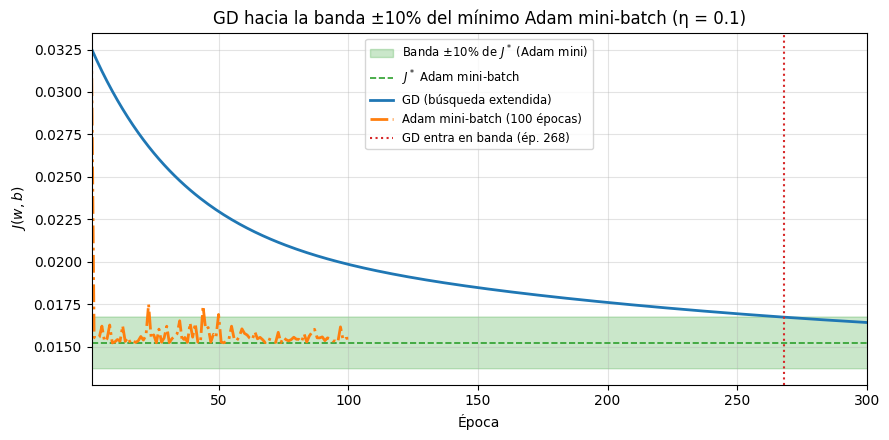

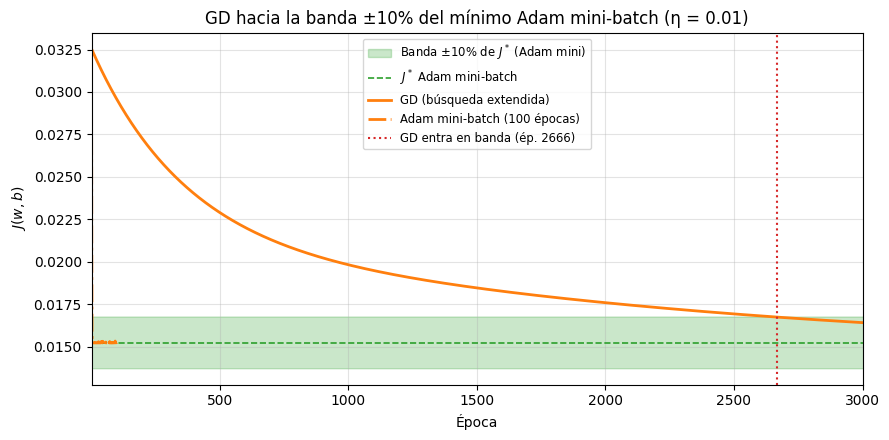

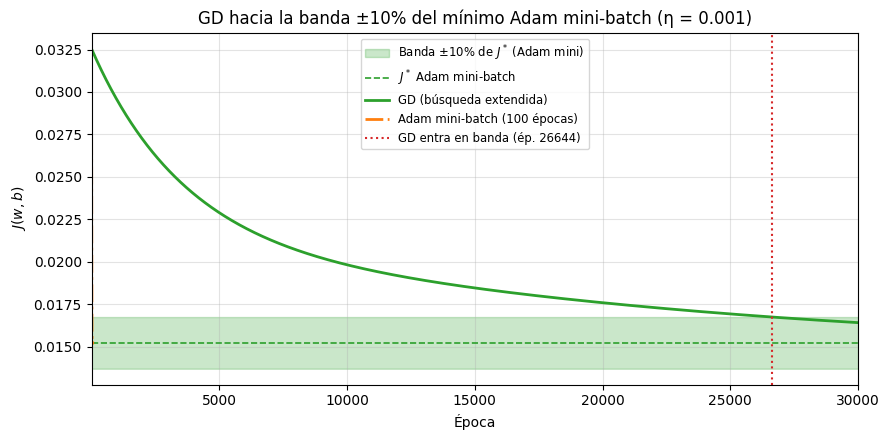

In [15]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display
except ImportError:

    def display(obj):
        print(obj)


# --- Parámetros del análisis (modificar entre corridas) ---
EPOCAS_GD_BUSQUEDA = 30000  # épocas máximas para buscar convergencia de GD
TOLERANCIA_BANDA_J = 0.10  # ±10 % respecto del mínimo J de Adam mini-batch
# Máximo del eje épocas en los gráficos GD vs banda (por η); None = usar todo el historial
LIMITE_EPOCAS_GRAFICO_GD_BANDA: dict[float, int | None] = {
    0.1: 300,
    0.01: 3000,
    0.001: None,
}


def _epoca_max_eje_grafico_gd_banda(eta: float, n_epocas_historial: int) -> int:
    """Devuelve el límite superior del eje épocas para el gráfico de banda."""
    for eta_clave, limite in LIMITE_EPOCAS_GRAFICO_GD_BANDA.items():
        if np.isclose(eta, eta_clave):
            return n_epocas_historial if limite is None else limite
    return n_epocas_historial


def _limites_banda_j(j_referencia: float, tolerancia: float) -> tuple[float, float]:
    """Intervalo [J·(1−tol), J·(1+tol)] alrededor del mínimo de referencia."""
    return j_referencia * (1.0 - tolerancia), j_referencia * (1.0 + tolerancia)


def primera_epoca_en_banda_j(
    historial_j: list[float],
    j_referencia: float,
    tolerancia: float = TOLERANCIA_BANDA_J,
) -> int | None:
    """Primera época (1-indexada) cuyo J está dentro de la banda ±tolerancia."""
    j_bajo, j_alto = _limites_banda_j(j_referencia, tolerancia)
    for epoca, j_val in enumerate(historial_j, start=1):
        if j_bajo <= j_val <= j_alto:
            return epoca
    return None


resultados_gd_banda: list[dict] = {}
historiales_J_gd_largo: dict[float, list[float]] = {}

for _eta in TASAS_APRENDIZAJE:
    j_adam_mini = min(historiales_J_adam_mini_batch[_eta])
    j_bajo, j_alto = _limites_banda_j(j_adam_mini, TOLERANCIA_BANDA_J)

    _, _, _hist_gd_largo, _ = entrenar_gradiente_descendente(
        _x,
        _y,
        tasa_aprendizaje=_eta,
        epocas=EPOCAS_GD_BUSQUEDA,
        w_inicial=W_INICIAL,
        b_inicial=B_INICIAL,
        semilla=None,
        registrar_trayectoria=False,
    )
    historiales_J_gd_largo[_eta] = _hist_gd_largo

    epoca_llegada = primera_epoca_en_banda_j(_hist_gd_largo, j_adam_mini, TOLERANCIA_BANDA_J)
    j_gd_final_largo = _hist_gd_largo[-1]

    resultados_gd_banda[_eta] = {
        "eta": _eta,
        "J_min_adam_mini": j_adam_mini,
        "J_banda_inferior": j_bajo,
        "J_banda_superior": j_alto,
        "epoca_gd_en_banda": epoca_llegada,
        "J_gd_final_busqueda": j_gd_final_largo,
        "J_gd_en_EPOCAS_COMPARATIVA": historiales_J_gd[_eta][-1],
    }

    if epoca_llegada is None:
        print(
            f"η = {_eta:g} | J* (Adam mini) = {j_adam_mini:.6f} | banda [{j_bajo:.6f}, {j_alto:.6f}] | "
            f"GD: no entró en {EPOCAS_GD_BUSQUEDA} épocas (J final = {j_gd_final_largo:.6f})"
        )
    else:
        print(
            f"η = {_eta:g} | J* (Adam mini) = {j_adam_mini:.6f} | banda [{j_bajo:.6f}, {j_alto:.6f}] | "
            f"GD alcanza la banda en época {epoca_llegada} (J = {_hist_gd_largo[epoca_llegada - 1]:.6f})"
        )

# --- Tabla resumen ---
filas_tabla = []
for _eta in TASAS_APRENDIZAJE:
    r = resultados_gd_banda[_eta]
    filas_tabla.append(
        {
            "η": r["eta"],
            "J* Adam mini-batch": r["J_min_adam_mini"],
            "Banda inferior (90%)": r["J_banda_inferior"],
            "Banda superior (110%)": r["J_banda_superior"],
            "Época GD en banda": r["epoca_gd_en_banda"]
            if r["epoca_gd_en_banda"] is not None
            else f">{EPOCAS_GD_BUSQUEDA}",
            "J GD (época EPOCAS_COMPARATIVA)": r["J_gd_en_EPOCAS_COMPARATIVA"],
            "J GD (fin búsqueda)": r["J_gd_final_busqueda"],
        }
    )

if pd is not None:
    display(pd.DataFrame(filas_tabla))
else:
    for fila in filas_tabla:
        print(fila)

# --- Gráficos: GD largo vs banda (un gráfico por η) ---
for _eta_plot in TASAS_APRENDIZAJE:
    r_plot = resultados_gd_banda[_eta_plot]
    hist_gd = historiales_J_gd_largo[_eta_plot]
    hist_adam = historiales_J_adam_mini_batch[_eta_plot]
    epocas_gd = np.arange(1, len(hist_gd) + 1)
    epocas_adam = np.arange(1, len(hist_adam) + 1)
    color_eta = COLORES_LEARNING_RATE[_eta_plot]

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.fill_between(
        epocas_gd,
        r_plot["J_banda_inferior"],
        r_plot["J_banda_superior"],
        alpha=0.25,
        color="tab:green",
        label=rf"Banda ±{TOLERANCIA_BANDA_J * 100:.0f}% de $J^*$ (Adam mini)",
    )
    ax.axhline(
        r_plot["J_min_adam_mini"],
        color="tab:green",
        ls="--",
        lw=1.2,
        label=r"$J^*$ Adam mini-batch",
    )
    ax.plot(
        epocas_gd,
        hist_gd,
        color=color_eta,
        lw=2,
        label="GD (búsqueda extendida)",
    )
    ax.plot(
        epocas_adam,
        hist_adam,
        color="tab:orange",
        lw=2,
        ls="-.",
        label=f"Adam mini-batch ({EPOCAS_COMPARATIVA} épocas)",
    )
    if r_plot["epoca_gd_en_banda"] is not None:
        ep = r_plot["epoca_gd_en_banda"]
        ax.axvline(
            ep,
            color="tab:red",
            ls=":",
            lw=1.5,
            label=f"GD entra en banda (ép. {ep})",
        )
    ax.set_xlabel("Época")
    ax.set_ylabel(r"$J(w,b)$")
    ax.set_title(
        f"GD hacia la banda ±{TOLERANCIA_BANDA_J * 100:.0f}% del mínimo Adam mini-batch (η = {_eta_plot:g})"
    )
    ax.set_xlim(1, _epoca_max_eje_grafico_gd_banda(_eta_plot, len(hist_gd)))
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize="small", loc="best")
    plt.tight_layout()
    plt.show()


## Conclusiones

Este notebook replica el experimento de la **Pregunta 1** con el mismo dataset sintético y el mismo criterio de señal, ruido e inicialización compartida. El objetivo fue contrastar **gradiente descendente (GD)** y **Adam mini-batch**  para las tres tasas de aprendizaje η ∈ {0,1, 0,01, 0,001}, y luego cuantificar **cuántas épocas adicionales** necesita GD para acercarse al mínimo alcanzado por Adam mini-batch.

### ¿Cuántas épocas necesita GD para “igualar” a Adam mini-batch?

Tomando como referencia **J\* ≈ 0,015219** (mínimo de Adam mini-batch con **η = 0,001**) y una banda de tolerancia **±10 %** ([0,0137, 0,0167]), se entrenó GD hasta **30 000 épocas**. En ningún η GD alcanzó esa banda dentro de las **100 épocas** iniciales; las primeras épocas de entrada fueron:

| η | Época en que GD entra en la banda | J de GD a 100 épocas |
|---|-----------------------------------|----------------------|
| 0,1 | **268** | 0,0198 (aún fuera de banda) |
| 0,01 | **2 666** | 0,0296 |
| 0,001 | **26 644** | 0,0322 |

El patrón es contundente: **cada reducción de η multiplica por ~10 el costo en épocas** para que GD se acerque al nivel de Adam. Incluso con **η = 0,1**, GD necesita **más del doble** de las 100 épocas del experimento principal; con **η = 0,001** la equivalencia aparece recién cerca de la **época 26 600**. Los gráficos de **J vs época** con la banda sombreada ilustran ese retraso: Adam mini-batch cae al rango objetivo casi de inmediato, mientras GD desciende de forma gradual.

### Comentarios

El experimento adicional confirma dos ideas centrales del trabajo práctico:

1. **La elección del optimizador importa tanto como la arquitectura** en un problema pequeño: con una sola neurona y tanh, Adam (sobre todo mini-batch) explota mejor el paisaje de **J(w, b)** que GD.
2. **La tasa de aprendizaje no es un detalle**: para GD define casi por completo si el entrenamiento converge en tiempo razonable; Adam amortigua ese efecto en η moderadas y altas.

Como extensión natural, convendría repetir el análisis de la banda ±10 % con otros tamaños de mini-batch o comparar trayectorias en el espacio **(w, b)** para visualizar por qué Adam avanza con pasos más eficaces en dirección al mínimo.
